# Install and Import Libraries

In [1]:
# Install required packages
!pip install nibabel scikit-image -q

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import nibabel as nib
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import warnings
import time
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} GPU(s)")
print("="*70)

2025-11-13 17:06:30.787148: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763053591.007451      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763053591.060890      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ ALL LIBRARIES IMPORTED SUCCESSFULLY
TensorFlow Version: 2.18.0
GPU Available: 2 GPU(s)


# Configuration

In [2]:
# Configuration
class Config:
    # Paths
    DATA_PATH = '/kaggle/input/brats20-dataset-training-validation'
    TRAIN_PATH ='/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
    VAL_PATH ='/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData'
    
    # Preprocessed data paths
    PROCESSED_PATH = '/kaggle/working/processed_data'
    TRAIN_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'train_images.npy')
    TRAIN_MASKS_PATH = os.path.join(PROCESSED_PATH, 'train_masks.npy')
    VAL_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'val_images.npy')
    VAL_MASKS_PATH = os.path.join(PROCESSED_PATH, 'val_masks.npy')
    TEST_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'test_images.npy')
    TEST_MASKS_PATH = os.path.join(PROCESSED_PATH, 'test_masks.npy')
    
    # Model parameters
    IMG_SIZE = 128
    CHANNELS = 4  # T1, T1ce, T2, FLAIR
    NUM_CLASSES = 4  # 0: background, 1: necrotic, 2: edema, 3: enhancing
    BATCH_SIZE = 16
    EPOCHS = 50
    LEARNING_RATE = 0.0001
    
    # Training parameters - PATIENT-LEVEL SPLIT
    TRAIN_SPLIT = 0.70
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    SLICE_RANGE = (30, 120)
    
    # Vision Transformer specific parameters
    PATCH_SIZE = 16
    EMBED_DIM = 512
    NUM_HEADS = 8
    NUM_LAYERS = 6
    MLP_DIM = 2048
    DROPOUT = 0.1
    
config = Config()
os.makedirs(config.PROCESSED_PATH, exist_ok=True)

print("="*70)
print("CONFIGURATION FOR VISION TRANSFORMER")
print("="*70)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Channels: {config.CHANNELS}")
print(f"Number of Classes: {config.NUM_CLASSES}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Epochs: {config.EPOCHS}")
print(f"\n🔧 Vision Transformer Parameters:")
print(f"   Patch Size: {config.PATCH_SIZE}x{config.PATCH_SIZE}")
print(f"   Embedding Dimension: {config.EMBED_DIM}")
print(f"   Number of Attention Heads: {config.NUM_HEADS}")
print(f"   Number of Transformer Layers: {config.NUM_LAYERS}")
print(f"   MLP Dimension: {config.MLP_DIM}")
print(f"   Dropout: {config.DROPOUT}")
print(f"\n📊 Data Split Strategy (PATIENT-LEVEL):")
print(f"   Train: {config.TRAIN_SPLIT*100:.0f}%")
print(f"   Validation: {config.VAL_SPLIT*100:.0f}%")
print(f"   Test: {config.TEST_SPLIT*100:.0f}%")
print("="*70)

CONFIGURATION FOR VISION TRANSFORMER
Image Size: 128x128
Channels: 4
Number of Classes: 4
Batch Size: 16
Epochs: 50

🔧 Vision Transformer Parameters:
   Patch Size: 16x16
   Embedding Dimension: 512
   Number of Attention Heads: 8
   Number of Transformer Layers: 6
   MLP Dimension: 2048
   Dropout: 0.1

📊 Data Split Strategy (PATIENT-LEVEL):
   Train: 70%
   Validation: 15%
   Test: 15%


# Data Loading Functions

In [3]:
def load_nifti(filepath):
    """Load NIfTI file and return numpy array"""
    return nib.load(filepath).get_fdata()

def get_patient_paths(base_path):
    """Get all patient directories"""
    patient_dirs = sorted(glob(os.path.join(base_path, 'BraTS20_*')))
    return patient_dirs

def load_patient_data(patient_dir):
    """Load all modalities and mask for a patient"""
    patient_id = os.path.basename(patient_dir)
    
    # Load modalities
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    # Load mask
    mask = load_nifti(os.path.join(patient_dir, f'{patient_id}_seg.nii'))
    
    # Stack modalities
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    return image, mask

def convert_mask_labels(mask):
    """Convert label 4 to label 3"""
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


# Split Patients

In [4]:
print("="*70)
print("STEP 1: SPLITTING PATIENTS (BEFORE EXTRACTING SLICES)")
print("="*70)

# Get all patient directories
all_patients = get_patient_paths(config.TRAIN_PATH)
print(f"\nTotal patients available: {len(all_patients)}")

# Split patients at PATIENT LEVEL
train_val_patients, test_patients = train_test_split(
    all_patients,
    test_size=config.TEST_SPLIT,
    random_state=42,
    shuffle=True
)

val_size_adjusted = config.VAL_SPLIT / (config.TRAIN_SPLIT + config.VAL_SPLIT)
train_patients, val_patients = train_test_split(
    train_val_patients,
    test_size=val_size_adjusted,
    random_state=42,
    shuffle=True
)

print(f"\n📊 PATIENT-LEVEL SPLIT:")
print(f"   Train patients: {len(train_patients)} ({len(train_patients)/len(all_patients)*100:.1f}%)")
print(f"   Validation patients: {len(val_patients)} ({len(val_patients)/len(all_patients)*100:.1f}%)")
print(f"   Test patients: {len(test_patients)} ({len(test_patients)/len(all_patients)*100:.1f}%)")

# Verify no overlap
train_set = set([os.path.basename(p) for p in train_patients])
val_set = set([os.path.basename(p) for p in val_patients])
test_set = set([os.path.basename(p) for p in test_patients])

assert len(train_set & val_set) == 0, "❌ Data leakage detected!"
assert len(train_set & test_set) == 0, "❌ Data leakage detected!"
assert len(val_set & test_set) == 0, "❌ Data leakage detected!"

print(f"\n✅ Verified: No overlap between splits!")
print("="*70)

STEP 1: SPLITTING PATIENTS (BEFORE EXTRACTING SLICES)

Total patients available: 369

📊 PATIENT-LEVEL SPLIT:
   Train patients: 257 (69.6%)
   Validation patients: 56 (15.2%)
   Test patients: 56 (15.2%)

✅ Verified: No overlap between splits!


# 2D Slice Extraction and Preprocessing Functions

In [5]:
def extract_2d_slices(image_3d, mask_3d, slice_range=(30, 120)):
    """Extract 2D slices from 3D volume"""
    slices_images = []
    slices_masks = []
    
    for slice_idx in range(slice_range[0], min(slice_range[1], image_3d.shape[2])):
        img_slice = image_3d[:, :, slice_idx, :]
        mask_slice = mask_3d[:, :, slice_idx]
        
        if np.sum(mask_slice) > 0:
            slices_images.append(img_slice)
            slices_masks.append(mask_slice)
    
    return slices_images, slices_masks

def preprocess_image(image, target_size=128):
    """Resize and normalize image"""
    resized = cv2.resize(image, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    
    normalized = np.zeros_like(resized)
    for i in range(resized.shape[-1]):
        channel = resized[:, :, i]
        if np.max(channel) > 0:
            normalized[:, :, i] = (channel - np.min(channel)) / (np.max(channel) - np.min(channel))
    
    return normalized.astype(np.float32)

def preprocess_mask(mask, target_size=128):
    """Resize mask"""
    resized = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return resized.astype(np.uint8)

print("✅ Slice extraction and preprocessing functions defined!")

✅ Slice extraction and preprocessing functions defined!


# Process Each Split Separately

In [6]:
def process_patient_list(patient_list, split_name):
    """Process a list of patients and extract slices"""
    print(f"\n{'='*70}")
    print(f"Processing {split_name} Set ({len(patient_list)} patients)")
    print(f"{'='*70}")
    
    all_images = []
    all_masks = []
    
    for patient_dir in tqdm(patient_list, desc=f"Processing {split_name}"):
        try:
            image_3d, mask_3d = load_patient_data(patient_dir)
            mask_3d = convert_mask_labels(mask_3d)
            slices_img, slices_mask = extract_2d_slices(image_3d, mask_3d, config.SLICE_RANGE)
            
            for img_slice, mask_slice in zip(slices_img, slices_mask):
                processed_img = preprocess_image(img_slice, config.IMG_SIZE)
                processed_mask = preprocess_mask(mask_slice, config.IMG_SIZE)
                
                all_images.append(processed_img)
                all_masks.append(processed_mask)
        
        except Exception as e:
            print(f"\n❌ Error processing {patient_dir}: {e}")
            continue
    
    all_images = np.array(all_images, dtype=np.float32)
    all_masks = np.array(all_masks, dtype=np.uint8)
    
    print(f"✅ {split_name} set processed: {len(all_images)} slices")
    
    return all_images, all_masks

print("\n" + "="*70)
print("STEP 2: EXTRACTING SLICES FROM EACH SPLIT")
print("="*70)

# Process training patients
train_images, train_masks = process_patient_list(train_patients, "TRAIN")

# Process validation patients
val_images, val_masks = process_patient_list(val_patients, "VALIDATION")

# Process test patients
test_images, test_masks = process_patient_list(test_patients, "TEST")

print("\n" + "="*70)
print("DATA PROCESSING COMPLETE - NO DATA LEAKAGE!")
print("="*70)
print(f"Train slices: {len(train_images):,}")
print(f"Validation slices: {len(val_images):,}")
print(f"Test slices: {len(test_images):,}")
print("="*70)


STEP 2: EXTRACTING SLICES FROM EACH SPLIT

Processing TRAIN Set (257 patients)


Processing TRAIN:  77%|███████▋  | 198/257 [04:10<01:10,  1.20s/it]


❌ Error processing /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_355: No such file or no access: '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_355/BraTS20_Training_355_seg.nii'


Processing TRAIN: 100%|██████████| 257/257 [05:25<00:00,  1.27s/it]


✅ TRAIN set processed: 15366 slices

Processing VALIDATION Set (56 patients)


Processing VALIDATION: 100%|██████████| 56/56 [01:04<00:00,  1.15s/it]


✅ VALIDATION set processed: 3530 slices

Processing TEST Set (56 patients)


Processing TEST: 100%|██████████| 56/56 [01:05<00:00,  1.16s/it]


✅ TEST set processed: 3386 slices

DATA PROCESSING COMPLETE - NO DATA LEAKAGE!
Train slices: 15,366
Validation slices: 3,530
Test slices: 3,386


# Save Processed Data

In [7]:
print("\n" + "="*70)
print("SAVING PROCESSED DATA")
print("="*70)

np.save(config.TRAIN_IMAGES_PATH, train_images)
np.save(config.TRAIN_MASKS_PATH, train_masks)
np.save(config.VAL_IMAGES_PATH, val_images)
np.save(config.VAL_MASKS_PATH, val_masks)
np.save(config.TEST_IMAGES_PATH, test_images)
np.save(config.TEST_MASKS_PATH, test_masks)

print(f"✅ All data saved to: {config.PROCESSED_PATH}")
print("="*70)


SAVING PROCESSED DATA
✅ All data saved to: /kaggle/working/processed_data


# Load Processed Data

In [8]:
# Uncomment to load pre-processed data:
 #train_images = np.load(config.TRAIN_IMAGES_PATH)
 #train_masks = np.load(config.TRAIN_MASKS_PATH)
 #val_images = np.load(config.VAL_IMAGES_PATH)
 #val_masks = np.load(config.VAL_MASKS_PATH)
 #test_images = np.load(config.TEST_IMAGES_PATH)
 #test_masks = np.load(config.TEST_MASKS_PATH)

print("="*70)
print("DATA SUMMARY")
print("="*70)
print(f"Train: {train_images.shape}")
print(f"Validation: {val_images.shape}")
print(f"Test: {test_images.shape}")
print("="*70)

DATA SUMMARY
Train: (15366, 128, 128, 4)
Validation: (3530, 128, 128, 4)
Test: (3386, 128, 128, 4)


# Visualize Sample Data

VISUALIZING SAMPLES


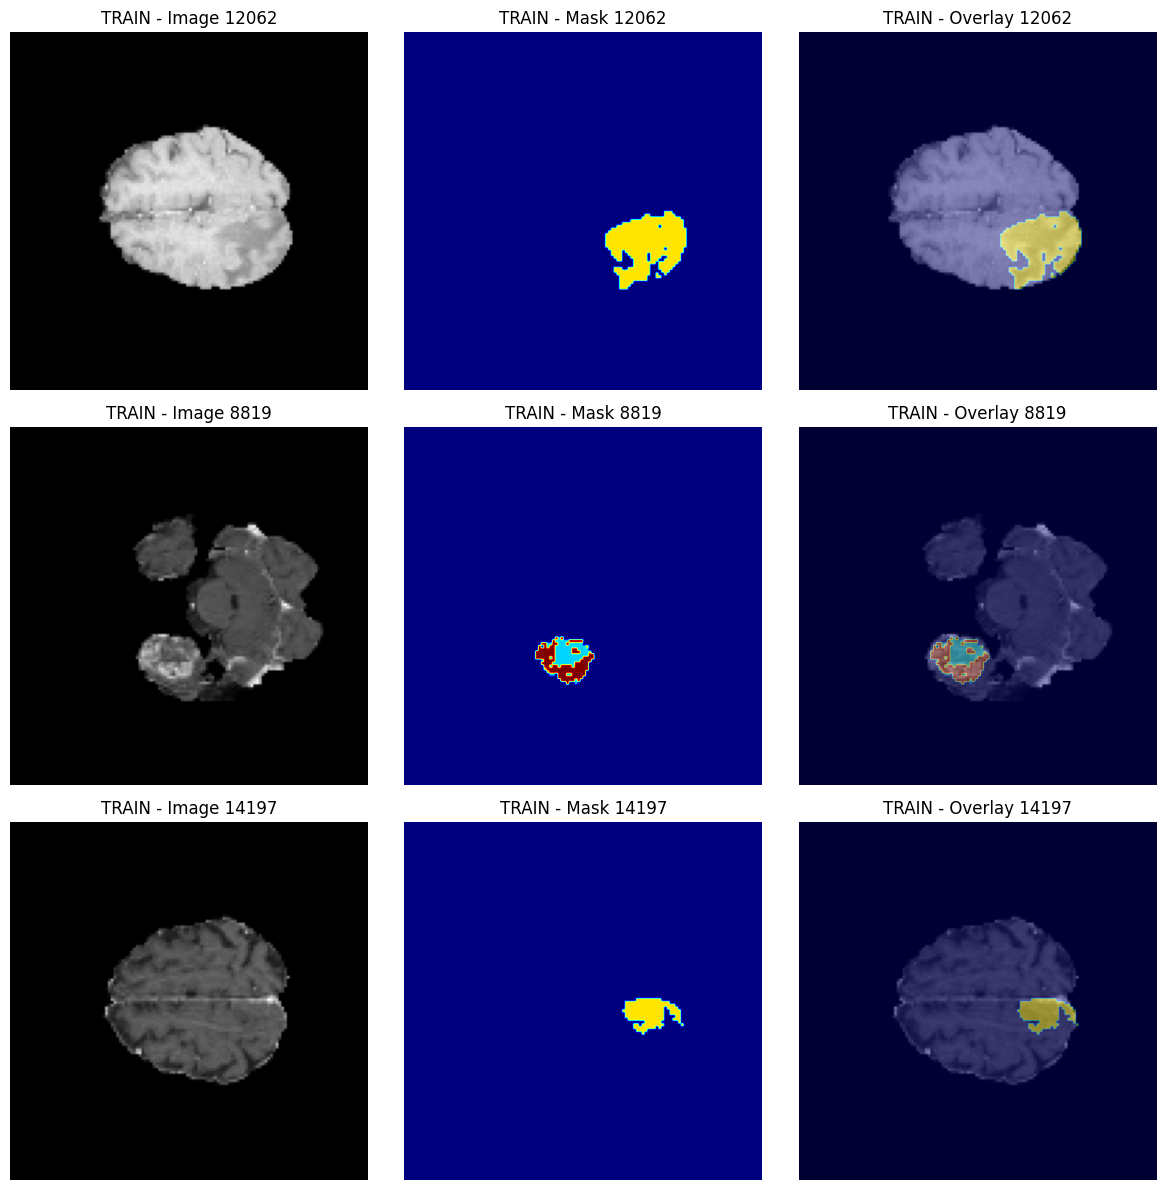

In [9]:
def visualize_samples(images, masks, title, num_samples=3):
    """Visualize samples"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        axes[i, 0].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 0].set_title(f'{title} - Image {idx}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 1].set_title(f'{title} - Mask {idx}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 2].imshow(masks[idx], cmap='jet', alpha=0.4, vmin=0, vmax=3)
        axes[i, 2].set_title(f'{title} - Overlay {idx}')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("="*70)
print("VISUALIZING SAMPLES")
print("="*70)
visualize_samples(train_images, train_masks, "TRAIN", num_samples=3)

# Data Augmentation

In [10]:
def augment_data(image, mask):
    """Apply random augmentation"""
    image = np.array(image, dtype=np.float32)
    mask = np.array(mask, dtype=np.uint8)
    
    if np.random.random() > 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)
    
    if np.random.random() > 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)
    
    k = np.random.randint(0, 4)
    if k > 0:
        image = np.rot90(image, k)
        mask = np.rot90(mask, k)
    
    if np.random.random() > 0.5:
        factor = np.random.uniform(0.8, 1.2)
        image = np.clip(image * factor, 0, 1)
    
    return image.astype(np.float32), mask.astype(np.uint8)

class DataGenerator(Sequence):
    def __init__(self, images, masks, batch_size=16, num_classes=4, augment=False, shuffle=True):
        self.images = images
        self.masks = masks
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))
    
    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.indices))
        batch_indices = self.indices[start_idx:end_idx]
        
        batch_size_actual = len(batch_indices)
        batch_images = np.zeros((batch_size_actual, *self.images.shape[1:]), dtype=np.float32)
        batch_masks = np.zeros((batch_size_actual, *self.masks.shape[1:]), dtype=np.uint8)
        
        for i, idx in enumerate(batch_indices):
            img = self.images[idx].copy()
            mask = self.masks[idx].copy()
            
            if self.augment:
                img, mask = augment_data(img, mask)
            
            batch_images[i] = img
            batch_masks[i] = mask
        
        batch_masks_categorical = tf.keras.utils.to_categorical(batch_masks, num_classes=self.num_classes)
        
        return batch_images, batch_masks_categorical
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = DataGenerator(train_images, train_masks, batch_size=config.BATCH_SIZE, 
                          num_classes=config.NUM_CLASSES, augment=True, shuffle=True)
val_gen = DataGenerator(val_images, val_masks, batch_size=config.BATCH_SIZE, 
                        num_classes=config.NUM_CLASSES, augment=False, shuffle=False)

print("="*70)
print("DATA GENERATORS CREATED")
print("="*70)
print(f"Training batches per epoch: {len(train_gen)}")
print(f"Validation batches per epoch: {len(val_gen)}")

# Test generator
sample_x, sample_y = train_gen[0]
print(f"\n✅ Generator test: X={sample_x.shape}, Y={sample_y.shape}")
print("="*70)

DATA GENERATORS CREATED
Training batches per epoch: 961
Validation batches per epoch: 221

✅ Generator test: X=(16, 128, 128, 4), Y=(16, 128, 128, 4)


# Build Vision Transformer Components

In [11]:
# ============================================================================
# VISION TRANSFORMER FOR PIXEL-WISE SEGMENTATION
# ============================================================================

# Patch Embedding with Positional Encoding (CORRECTED)
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim, max_patches=256, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.max_patches = max_patches
        
        self.projection = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding='valid'
        )
        
        # Create positional embedding with maximum size upfront
        self.pos_embedding = layers.Embedding(
            input_dim=max_patches, 
            output_dim=embed_dim
        )
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        x = self.projection(x)  # (batch, h/patch_size, w/patch_size, embed_dim)
        h, w = tf.shape(x)[1], tf.shape(x)[2]
        
        # Flatten patches
        x = tf.reshape(x, [batch_size, h * w, self.embed_dim])
        
        # Add learnable positional embeddings
        num_patches = h * w
        positions = tf.range(start=0, limit=num_patches, delta=1)
        pos_emb = self.pos_embedding(positions)
        x = x + pos_emb
        
        return x, h, w
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "patch_size": self.patch_size,
            "embed_dim": self.embed_dim,
            "max_patches": self.max_patches
        })
        return config
     
# Multi-Head Self-Attention
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        
        self.query = layers.Dense(embed_dim)
        self.key = layers.Dense(embed_dim)
        self.value = layers.Dense(embed_dim)
        self.combine = layers.Dense(embed_dim)
        
    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output
    
    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])
    
    def call(self, x):
        batch_size = tf.shape(x)[0]
        
        query = self.query(x)
        key = self.key(x)
        value = self.value(x)
        
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        
        attention = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine(concat_attention)
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads
        })
        return config

# Transformer Block (CORRECTED)
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, dropout_rate=None, **kwargs):
        super().__init__(**kwargs)
        
        # Handle both 'dropout' and 'dropout_rate' for backward compatibility
        if dropout_rate is not None:
            dropout = dropout_rate
            
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout  # Store as dropout_rate for consistency
        
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout)
    
    def call(self, x, training=False):
        # Attention block
        x1 = self.layernorm1(x)
        attention_output = self.att(x1)
        attention_output = self.dropout(attention_output, training=training)
        x2 = x + attention_output
        
        # MLP block
        x3 = self.layernorm2(x2)
        mlp_output = self.mlp(x3, training=training)
        return x2 + mlp_output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "mlp_dim": self.mlp_dim,
            "dropout_rate": self.dropout_rate  # Matches what was saved
        })
        return config
  
print("✅ Vision Transformer components defined!")

✅ Vision Transformer components defined!


# Build Complete ViT Segmentation Model

In [12]:
# ============================================================================
# VISION TRANSFORMER WITH HIERARCHICAL FEATURES (CORRECTED)
# ============================================================================

# Custom layer to reshape transformer output back to spatial format
class ReshapeToSpatial(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
    
    def call(self, inputs):
        x, h, w = inputs
        batch_size = tf.shape(x)[0]
        x = tf.reshape(x, [batch_size, h, w, self.embed_dim])
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config


def build_hybrid_vit_segmentation(
    input_shape=(128, 128, 4),
    num_classes=4,
    patch_size=16,
    embed_dim=512,
    num_heads=8,
    mlp_dim=2048,
    num_layers=6,
    dropout=0.1
):
    """
    Hybrid Vision Transformer with CNN features for better segmentation
    Combines patch-based attention with convolutional features
    """
    inputs = layers.Input(shape=input_shape)
    
    # Early CNN feature extraction (like U-Net encoder)
    conv1 = layers.Conv2D(64, 3, padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    conv1 = layers.Conv2D(64, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    skip1 = layers.Activation('relu')(conv1)  # 128x128x64
    
    pool1 = layers.MaxPooling2D(2)(skip1)  # 64x64
    
    conv2 = layers.Conv2D(128, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    conv2 = layers.Conv2D(128, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    skip2 = layers.Activation('relu')(conv2)  # 64x64x128
    
    pool2 = layers.MaxPooling2D(2)(skip2)  # 32x32
    
    conv3 = layers.Conv2D(256, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    conv3 = layers.Conv2D(256, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    skip3 = layers.Activation('relu')(conv3)  # 32x32x256
    
    pool3 = layers.MaxPooling2D(2)(skip3)  # 16x16
    
    # Patch embedding from reduced feature maps
    patch_embed = PatchEmbedding(patch_size=4, embed_dim=embed_dim)  # 4x4 patches on 16x16
    x_patches = patch_embed(pool3)
    
    # Unpack the tuple - x_patches is (x, h, w)
    x = x_patches[0]
    h_patches = x_patches[1]
    w_patches = x_patches[2]
    
    # Transformer blocks
    for _ in range(num_layers):
        transformer = TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
        x = transformer(x)
    
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Reshape back to spatial using custom layer
    reshape_layer = ReshapeToSpatial(embed_dim)
    x = reshape_layer([x, h_patches, w_patches])  # 4x4x512
    
    # Decoder with skip connections
    # Upsample: 4x4 -> 16x16
    up1 = layers.Conv2DTranspose(256, 3, strides=4, padding='same')(x)
    up1 = layers.BatchNormalization()(up1)
    up1 = layers.Activation('relu')(up1)
    
    # Upsample: 16x16 -> 32x32 with skip3
    up2 = layers.Conv2DTranspose(256, 3, strides=2, padding='same')(up1)
    up2 = layers.Concatenate()([up2, skip3])  # Skip connection
    up2 = layers.Conv2D(256, 3, padding='same')(up2)
    up2 = layers.BatchNormalization()(up2)
    up2 = layers.Activation('relu')(up2)
    up2 = layers.Conv2D(256, 3, padding='same')(up2)
    up2 = layers.BatchNormalization()(up2)
    up2 = layers.Activation('relu')(up2)
    
    # Upsample: 32x32 -> 64x64 with skip2
    up3 = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(up2)
    up3 = layers.Concatenate()([up3, skip2])  # Skip connection
    up3 = layers.Conv2D(128, 3, padding='same')(up3)
    up3 = layers.BatchNormalization()(up3)
    up3 = layers.Activation('relu')(up3)
    up3 = layers.Conv2D(128, 3, padding='same')(up3)
    up3 = layers.BatchNormalization()(up3)
    up3 = layers.Activation('relu')(up3)
    
    # Upsample: 64x64 -> 128x128 with skip1
    up4 = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(up3)
    up4 = layers.Concatenate()([up4, skip1])  # Skip connection
    up4 = layers.Conv2D(64, 3, padding='same')(up4)
    up4 = layers.BatchNormalization()(up4)
    up4 = layers.Activation('relu')(up4)
    up4 = layers.Conv2D(64, 3, padding='same')(up4)
    up4 = layers.BatchNormalization()(up4)
    up4 = layers.Activation('relu')(up4)
    
    # Final output
    outputs = layers.Conv2D(num_classes, 1, padding='same', activation='softmax')(up4)
    
    model = models.Model(inputs, outputs, name='Hybrid-ViT-Segmentation')
    return model


# Build the model
vit_model = build_hybrid_vit_segmentation(
    input_shape=(config.IMG_SIZE, config.IMG_SIZE, config.CHANNELS),
    num_classes=config.NUM_CLASSES,
    patch_size=config.PATCH_SIZE,
    embed_dim=config.EMBED_DIM,
    num_heads=config.NUM_HEADS,
    mlp_dim=config.MLP_DIM,
    num_layers=config.NUM_LAYERS,
    dropout=config.DROPOUT
)

print("\n✅ Hybrid Vision Transformer built!")
print(f"Total Parameters: {vit_model.count_params():,}")
vit_model.summary()

I0000 00:00:1763054091.509478      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763054091.511162      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



✅ Hybrid Vision Transformer built!
Total Parameters: 26,760,644


Model: "Hybrid-ViT-Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 26,760,644 (102.08 MB)

 Trainable params: 26,756,548 (102.07 MB)

 Non-trainable params: 4,096 (16.00 KB)

# Loss Functions and Metrics

In [13]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for multi-class segmentation"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Dice loss"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return 1 - dice_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    """Combined Dice and Categorical Crossentropy loss"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    dice = dice_loss(y_true, y_pred)
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return dice + tf.reduce_mean(ce)

def iou_score(y_true, y_pred, smooth=1e-6):
    """Intersection over Union"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def pixel_accuracy(y_true, y_pred):
    """Pixel-wise accuracy"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_class = tf.argmax(y_true, axis=-1)
    y_pred_class = tf.argmax(y_pred, axis=-1)
    correct = tf.cast(tf.equal(y_true_class, y_pred_class), tf.float32)
    return tf.reduce_mean(correct)

print("✅ Loss functions and metrics defined!")

✅ Loss functions and metrics defined!


# Compile Model

In [14]:
print("="*70)
print("COMPILING VISION TRANSFORMER MODEL")
print("="*70)

vit_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, pixel_accuracy, 'categorical_accuracy']
)

print("✅ Model compiled successfully!")
print(f"\nOptimizer: Adam")
print(f"Learning Rate: {0.0001}")
print(f"Loss: Combined (Dice + Categorical Crossentropy)")
print(f"Metrics: Dice Coefficient, IoU Score, Pixel Accuracy, Categorical Accuracy")
print("="*70)

COMPILING VISION TRANSFORMER MODEL
✅ Model compiled successfully!

Optimizer: Adam
Learning Rate: 0.0001
Loss: Combined (Dice + Categorical Crossentropy)
Metrics: Dice Coefficient, IoU Score, Pixel Accuracy, Categorical Accuracy


# Configure Callbacks

In [15]:
print("="*70)
print("CONFIGURING CALLBACKS")
print("="*70)

# ModelCheckpoint
checkpoint = ModelCheckpoint(
    filepath='/kaggle/working/best_vit_model.h5',
    monitor='val_dice_coefficient',
    mode='max',
    save_best_only=True,
    verbose=1
)

# EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Custom epoch summary callback
class EpochSummaryCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"{'='*70}")
        print(f"Epoch {epoch+1} Summary:")
        print(f"  Train → Loss: {logs['loss']:.4f} | Dice: {logs['dice_coefficient']:.4f} | IoU: {logs['iou_score']:.4f}")
        print(f"  Val   → Loss: {logs['val_loss']:.4f} | Dice: {logs['val_dice_coefficient']:.4f} | IoU: {logs['val_iou_score']:.4f}")
        print(f"{'='*70}\n")

epoch_summary = EpochSummaryCallback()

callbacks = [checkpoint, early_stopping, reduce_lr, epoch_summary]

print("✅ Callbacks configured:")
print("   • ModelCheckpoint: Saves best model based on val_dice_coefficient")
print("   • EarlyStopping: Stops if no improvement for 5 epochs")
print("   • ReduceLROnPlateau: Reduces LR when val_loss plateaus")
print("   • EpochSummaryCallback: Displays clean epoch summaries")
print("="*70)

CONFIGURING CALLBACKS
✅ Callbacks configured:
   • ModelCheckpoint: Saves best model based on val_dice_coefficient
   • EarlyStopping: Stops if no improvement for 5 epochs
   • ReduceLROnPlateau: Reduces LR when val_loss plateaus
   • EpochSummaryCallback: Displays clean epoch summaries


# Train Vision Transformer

In [16]:
print("\n" + "="*70)
print("STARTING VISION TRANSFORMER TRAINING")
print("="*70)
print(f"Epochs: {1}")
print(f"Batch size: {16}")
print(f"Training samples: {len(train_images):,}")
print(f"Validation samples: {len(val_images):,}")
print(f"Training batches per epoch: {len(train_gen)}")
print(f"Validation batches per epoch: {len(val_gen)}")
print("="*70)


# Clear memory
import gc
tf.keras.backend.clear_session()
gc.collect()

# Train model
history = vit_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("✅ TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)


STARTING VISION TRANSFORMER TRAINING
Epochs: 1
Batch size: 16
Training samples: 15,366
Validation samples: 3,530
Training batches per epoch: 961
Validation batches per epoch: 221
Epoch 1/50


I0000 00:00:1763054118.801860     123 service.cc:148] XLA service 0x7cc1ac00b6a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763054118.802825     123 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763054118.802845     123 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763054122.584512     123 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763054157.788774     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


750/961 ━━━━━━━━━━━━━━━━━━━━ 44s 212ms/step - categorical_accuracy: 0.9124 - dice_coefficient: 0.6924 - iou_score: 0.5559 - loss: 0.7959 - pixel_accuracy: 0.9124

E0000 00:00:1763054326.806791     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763054327.032727     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763054329.429824     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763054329.657428     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - categorical_accuracy: 0.9248 - dice_coefficient: 0.7222 - iou_score: 0.5923 - loss: 0.7111 - pixel_accuracy: 0.9248

...

Epoch 38 Summary:
  Train → Loss: 0.0187 | Dice: 0.9938 | IoU: 0.9876
  Val   → Loss: 0.0445 | Dice: 0.9894 | IoU: 0.9792

961/961 ━━━━━━━━━━━━━━━━━━━━ 226s 235ms/step - categorical_accuracy: 0.9952 - dice_coefficient: 0.9938 - iou_score: 0.9876 - loss: 0.0187 - pixel_accuracy: 0.9952 - val_categorical_accuracy: 0.9905 - val_dice_coefficient: 0.9894 - val_iou_score: 0.9792 - val_loss: 0.0445 - val_pixel_accuracy: 0.9905 - learning_rate: 6.2500e-06
Epoch 39/50
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - categorical_accuracy: 0.9952 - dice_coefficient: 0.9938 - iou_score: 0.9876 - loss: 0.0186 - pixel_accuracy: 0.9952
Epoch 39: val_dice_coefficient did not improve from 0.98940
Epoch 39 Summary:
  Train → Loss: 0.0185 | Dice: 0.9938 | IoU: 0.9877
  Val   → Loss: 0.0448 | Dice: 0.9893 | IoU: 0.9790

961/961 ━━━━━━━━━━━━━━━━━━━━ 225s 234ms/step - categorical_accuracy: 0.9952 - dice_coefficient: 0.9938 - iou_score: 0.9876 - loss: 0.0186 - pixel_accuracy: 0.9952 - val_categorical_accuracy: 0

Epoch 40 Summary:
  Train → Loss: 0.0184 | Dice: 0.9938 | IoU: 0.9878
  Val   → Loss: 0.0442 | Dice: 0.9895 | IoU: 0.9793

961/961 ━━━━━━━━━━━━━━━━━━━━ 226s 235ms/step - categorical_accuracy: 0.9953 - dice_coefficient: 0.9938 - iou_score: 0.9878 - loss: 0.0184 - pixel_accuracy: 0.9953 - val_categorical_accuracy: 0.9906 - val_dice_coefficient: 0.9895 - val_iou_score: 0.9793 - val_loss: 0.0442 - val_pixel_accuracy: 0.9906 - learning_rate: 6.2500e-06
Epoch 41/50
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - categorical_accuracy: 0.9953 - dice_coefficient: 0.9939 - iou_score: 0.9879 - loss: 0.0182 - pixel_accuracy: 0.9953
Epoch 41: val_dice_coefficient improved from 0.98949 to 0.98950, saving model to /kaggle/working/best_vit_model.h5



Epoch 41: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
Epoch 41 Summary:
  Train → Loss: 0.0183 | Dice: 0.9939 | IoU: 0.9878
  Val   → Loss: 0.0438 | Dice: 0.9895 | IoU: 0.9794

961/961 ━━━━━━━━━━━━━━━━━━━━ 226s 236ms/step - categorical_accuracy: 0.9953 - dice_coefficient: 0.9939 - iou_score: 0.9879 - loss: 0.0182 - pixel_accuracy: 0.9953 - val_categorical_accuracy: 0.9906 - val_dice_coefficient: 0.9895 - val_iou_score: 0.9794 - val_loss: 0.0438 - val_pixel_accuracy: 0.9906 - learning_rate: 6.2500e-06
Epoch 42/50
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - categorical_accuracy: 0.9953 - dice_coefficient: 0.9939 - iou_score: 0.9878 - loss: 0.0183 - pixel_accuracy: 0.9953
Epoch 42: val_dice_coefficient did not improve from 0.98950
Epoch 42 Summary:
  Train → Loss: 0.0182 | Dice: 0.9939 | IoU: 0.9879
  Val   → Loss: 0.0444 | Dice: 0.9895 | IoU: 0.9793

961/961 ━━━━━━━━━━━━━━━━━━━━ 225s 234ms/step - categorical_accuracy: 0.9953 - dice_coefficient: 0.9939 - iou_score:

Epoch 45 Summary:
  Train → Loss: 0.0179 | Dice: 0.9940 | IoU: 0.9881
  Val   → Loss: 0.0446 | Dice: 0.9895 | IoU: 0.9794

961/961 ━━━━━━━━━━━━━━━━━━━━ 226s 235ms/step - categorical_accuracy: 0.9954 - dice_coefficient: 0.9940 - iou_score: 0.9881 - loss: 0.0180 - pixel_accuracy: 0.9954 - val_categorical_accuracy: 0.9906 - val_dice_coefficient: 0.9895 - val_iou_score: 0.9794 - val_loss: 0.0446 - val_pixel_accuracy: 0.9906 - learning_rate: 3.1250e-06
Epoch 46/50
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - categorical_accuracy: 0.9954 - dice_coefficient: 0.9941 - iou_score: 0.9882 - loss: 0.0178 - pixel_accuracy: 0.9954
Epoch 46: val_dice_coefficient did not improve from 0.98954

Epoch 46: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-06.
Epoch 46 Summary:
  Train → Loss: 0.0179 | Dice: 0.9940 | IoU: 0.9881
  Val   → Loss: 0.0444 | Dice: 0.9895 | IoU: 0.9794

961/961 ━━━━━━━━━━━━━━━━━━━━ 225s 234ms/step - categorical_accuracy: 0.9954 - dice_coefficient: 0.9941 - iou_score:

Epoch 48 Summary:
  Train → Loss: 0.0178 | Dice: 0.9941 | IoU: 0.9882
  Val   → Loss: 0.0447 | Dice: 0.9896 | IoU: 0.9795

961/961 ━━━━━━━━━━━━━━━━━━━━ 226s 235ms/step - categorical_accuracy: 0.9954 - dice_coefficient: 0.9941 - iou_score: 0.9882 - loss: 0.0178 - pixel_accuracy: 0.9954 - val_categorical_accuracy: 0.9906 - val_dice_coefficient: 0.9896 - val_iou_score: 0.9795 - val_loss: 0.0447 - val_pixel_accuracy: 0.9906 - learning_rate: 1.5625e-06
Epoch 49/50
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - categorical_accuracy: 0.9954 - dice_coefficient: 0.9940 - iou_score: 0.9882 - loss: 0.0178 - pixel_accuracy: 0.9954
Epoch 49: val_dice_coefficient did not improve from 0.98956
Epoch 49 Summary:
  Train → Loss: 0.0177 | Dice: 0.9941 | IoU: 0.9882
  Val   → Loss: 0.0447 | Dice: 0.9895 | IoU: 0.9794

961/961 ━━━━━━━━━━━━━━━━━━━━ 225s 235ms/step - categorical_accuracy: 0.9954 - dice_coefficient: 0.9940 - iou_score: 0.9882 - loss: 0.0178 - pixel_accuracy: 0.9954 - val_categorical_accuracy: 0

# Plot Training Curves

PLOTTING TRAINING CURVES


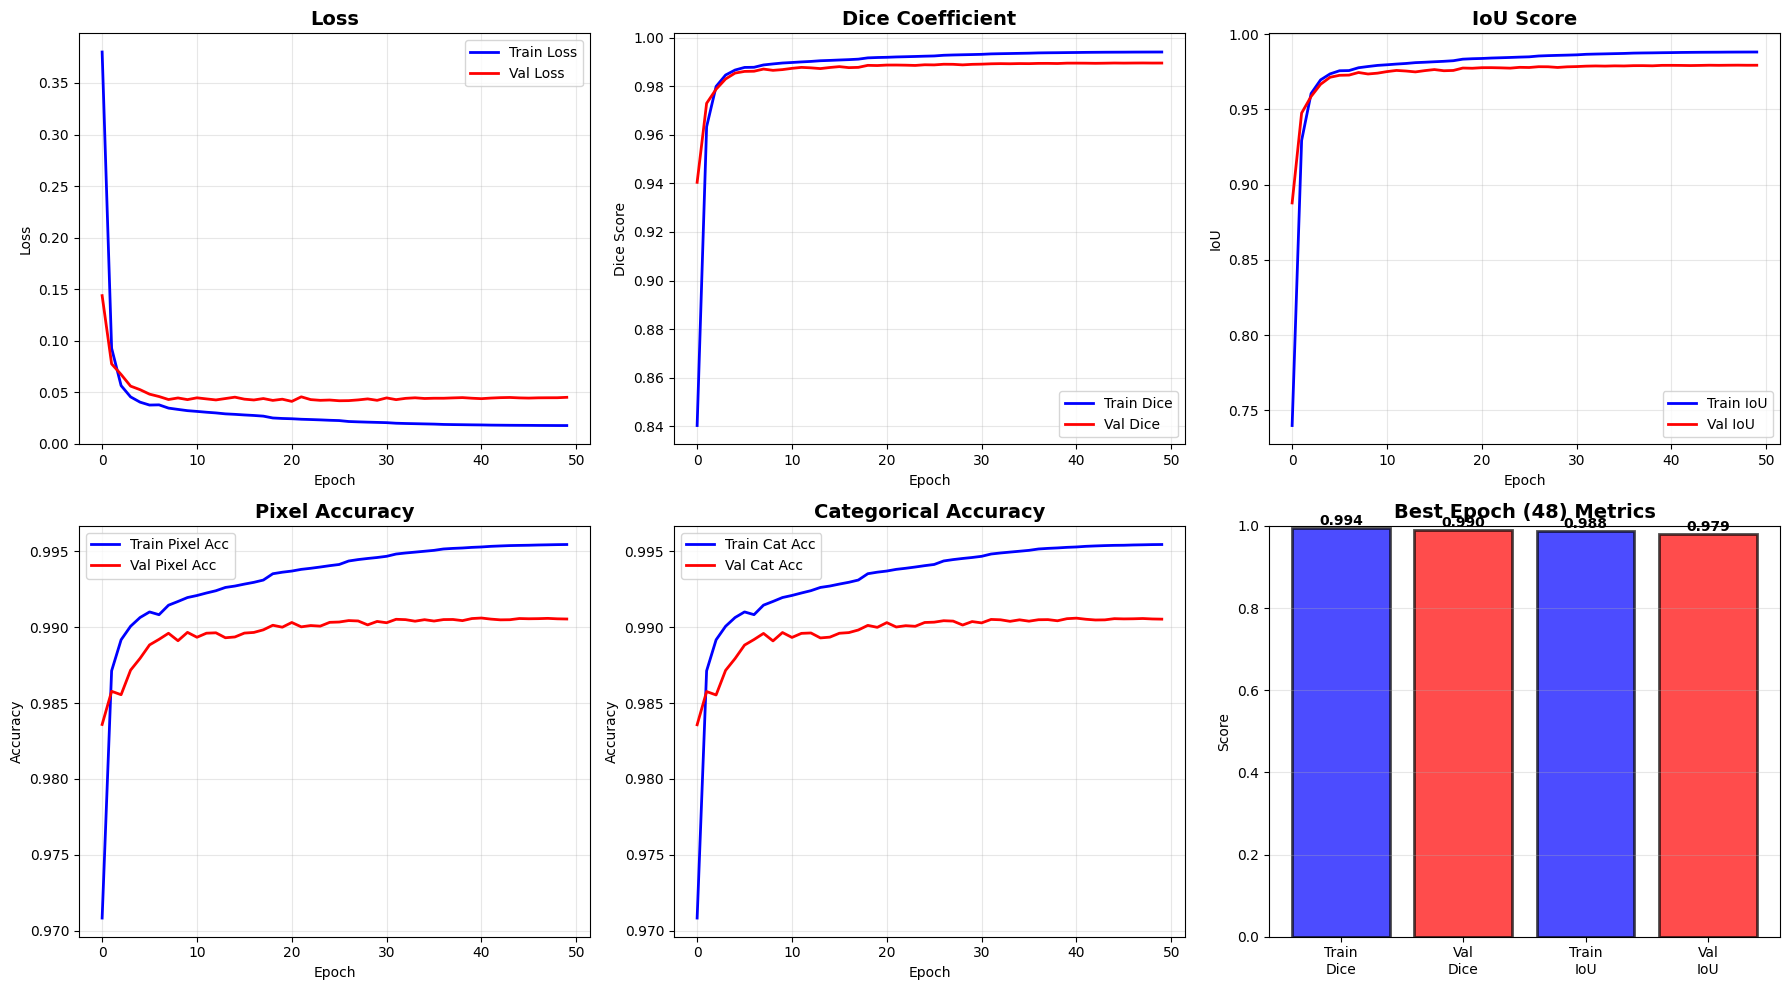


📊 BEST EPOCH: 48/1
   Val Dice: 0.9896
   Val IoU: 0.9795
   Val Loss: 0.0447
   Train Dice: 0.9941


In [24]:
def plot_training_curves(history):
    """Plot training and validation curves"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Dice Coefficient
    axes[0, 1].plot(history.history['dice_coefficient'], label='Train Dice', linewidth=2, color='blue')
    axes[0, 1].plot(history.history['val_dice_coefficient'], label='Val Dice', linewidth=2, color='red')
    axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # IoU Score
    axes[0, 2].plot(history.history['iou_score'], label='Train IoU', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_iou_score'], label='Val IoU', linewidth=2, color='red')
    axes[0, 2].set_title('IoU Score', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('IoU')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Pixel Accuracy
    axes[1, 0].plot(history.history['pixel_accuracy'], label='Train Pixel Acc', linewidth=2, color='blue')
    axes[1, 0].plot(history.history['val_pixel_accuracy'], label='Val Pixel Acc', linewidth=2, color='red')
    axes[1, 0].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Categorical Accuracy
    axes[1, 1].plot(history.history['categorical_accuracy'], label='Train Cat Acc', linewidth=2, color='blue')
    axes[1, 1].plot(history.history['val_categorical_accuracy'], label='Val Cat Acc', linewidth=2, color='red')
    axes[1, 1].set_title('Categorical Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Best Epoch Performance
    best_epoch = np.argmax(history.history['val_dice_coefficient'])
    metrics = ['Train\nDice', 'Val\nDice', 'Train\nIoU', 'Val\nIoU']
    values = [
        history.history['dice_coefficient'][best_epoch],
        history.history['val_dice_coefficient'][best_epoch],
        history.history['iou_score'][best_epoch],
        history.history['val_iou_score'][best_epoch]
    ]
    colors = ['blue', 'red', 'blue', 'red']
    
    bars = axes[1, 2].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[1, 2].set_title(f'Best Epoch ({best_epoch+1}) Metrics', fontsize=14, fontweight='bold')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].set_ylim([0, 1])
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                       f'{val:.3f}',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/vit_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

print("="*70)
print("PLOTTING TRAINING CURVES")
print("="*70)

plot_training_curves(history)

# Print best metrics
best_epoch = np.argmax(history.history['val_dice_coefficient'])
print(f"\n📊 BEST EPOCH: {best_epoch + 1}/1")
print(f"   Val Dice: {history.history['val_dice_coefficient'][best_epoch]:.4f}")
print(f"   Val IoU: {history.history['val_iou_score'][best_epoch]:.4f}")
print(f"   Val Loss: {history.history['val_loss'][best_epoch]:.4f}")
print(f"   Train Dice: {history.history['dice_coefficient'][best_epoch]:.4f}")

# Load Best Model

In [25]:
print("="*70)
print("LOADING BEST VISION TRANSFORMER MODEL")
print("="*70)

best_vit_model = keras.models.load_model(
    '/kaggle/working/best_vit_model.h5',
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score': iou_score,
        'pixel_accuracy': pixel_accuracy,
        'PatchEmbedding': PatchEmbedding,
        'MultiHeadSelfAttention': MultiHeadSelfAttention,
        'TransformerBlock': TransformerBlock,
        'ReshapeToSpatial': ReshapeToSpatial
    }
)

print("✅ Best model loaded successfully!")
print(f"Model file: /kaggle/working/best_vit_model.h5")
print("="*70)

LOADING BEST VISION TRANSFORMER MODEL


✅ Best model loaded successfully!
Model file: /kaggle/working/best_vit_model.h5


# Evaluate on Test Set

In [26]:
test_masks_categorical = tf.keras.utils.to_categorical(test_masks, num_classes=4)

print("="*70)
print("EVALUATING VISION TRANSFORMER ON TEST SET")
print("="*70)
print(f"Test samples: {len(test_images):,}")
print(f"Test batches: {int(np.ceil(len(test_images) / 16))}")
print("\nEvaluating...")

test_results = best_vit_model.evaluate(
    test_images, 
    test_masks_categorical, 
    batch_size=16,
    verbose=1
)

print("\n" + "="*70)
print("TEST SET RESULTS (UNSEEN PATIENTS)")
print("="*70)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test IoU Score: {test_results[2]:.4f}")
print(f"Test Pixel Accuracy: {test_results[3]:.4f}")
print(f"Test Categorical Accuracy: {test_results[4]:.4f}")
print("="*70)

EVALUATING VISION TRANSFORMER ON TEST SET
Test samples: 3,386
Test batches: 212

Evaluating...
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - categorical_accuracy: 0.9900 - dice_coefficient: 0.9891 - iou_score: 0.9785 - loss: 0.0485 - pixel_accuracy: 0.9900

TEST SET RESULTS (UNSEEN PATIENTS)
Test Loss: 0.0425
Test Dice Coefficient: 0.9901
Test IoU Score: 0.9805
Test Pixel Accuracy: 0.9911
Test Categorical Accuracy: 0.9911


# Make Predictions

In [27]:
print("MAKING PREDICTIONS ON TEST SET")
print("="*70)

test_predictions = best_vit_model.predict(test_images, batch_size=config.BATCH_SIZE, verbose=1)
test_predictions_classes = np.argmax(test_predictions, axis=-1)

print(f"\n✅ Predictions complete!")
print(f"Predictions shape: {test_predictions.shape}")
print(f"Predicted classes shape: {test_predictions_classes.shape}")
print(f"Unique predicted classes: {np.unique(test_predictions_classes)}")
print("="*70)

MAKING PREDICTIONS ON TEST SET
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step

✅ Predictions complete!
Predictions shape: (3386, 128, 128, 4)
Predicted classes shape: (3386, 128, 128)
Unique predicted classes: [0 1 2 3]


# Visualize Predictions

VISUALIZING TEST SET PREDICTIONS


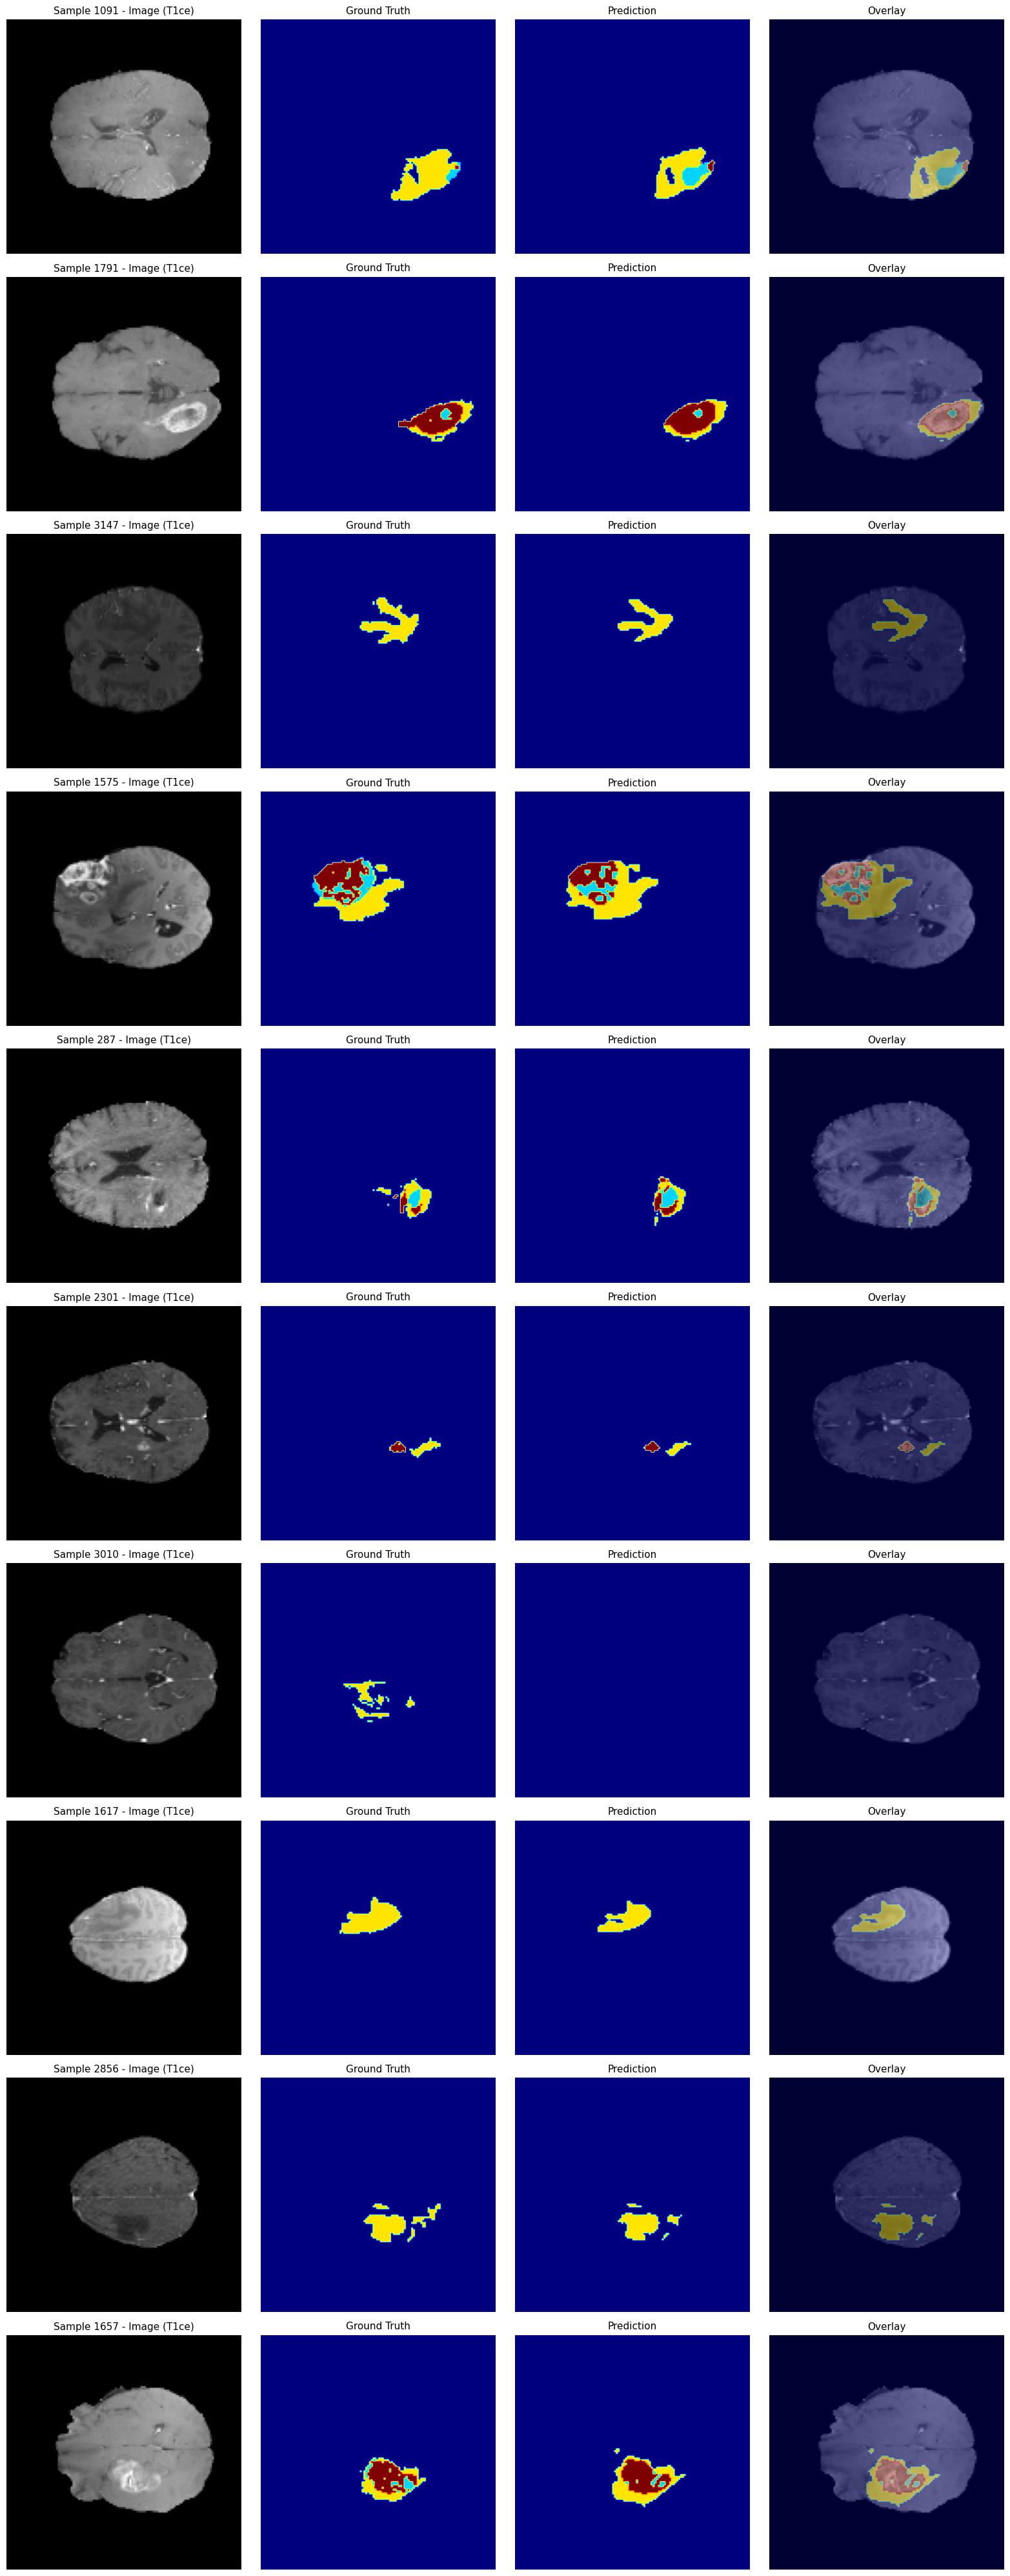

In [28]:
def visualize_predictions(images, true_masks, pred_masks, num_samples=10):
    """Visualize predictions"""
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i, idx in enumerate(indices):
        # Original image (T1ce channel)
        axes[i, 0].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 0].set_title(f'Sample {idx} - Image (T1ce)', fontsize=11)
        axes[i, 0].axis('off')
        
        # Ground truth mask
        axes[i, 1].imshow(true_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 1].set_title('Ground Truth', fontsize=11)
        axes[i, 1].axis('off')
        
        # Predicted mask
        axes[i, 2].imshow(pred_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 2].set_title('Prediction', fontsize=11)
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 3].imshow(pred_masks[idx], cmap='jet', alpha=0.4, vmin=0, vmax=3)
        axes[i, 3].set_title('Overlay', fontsize=11)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/vit_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

print("="*70)
print("VISUALIZING TEST SET PREDICTIONS")
print("="*70)

visualize_predictions(test_images, test_masks, test_predictions_classes, num_samples=10)

# Error Maps

VISUALIZING ERROR MAPS


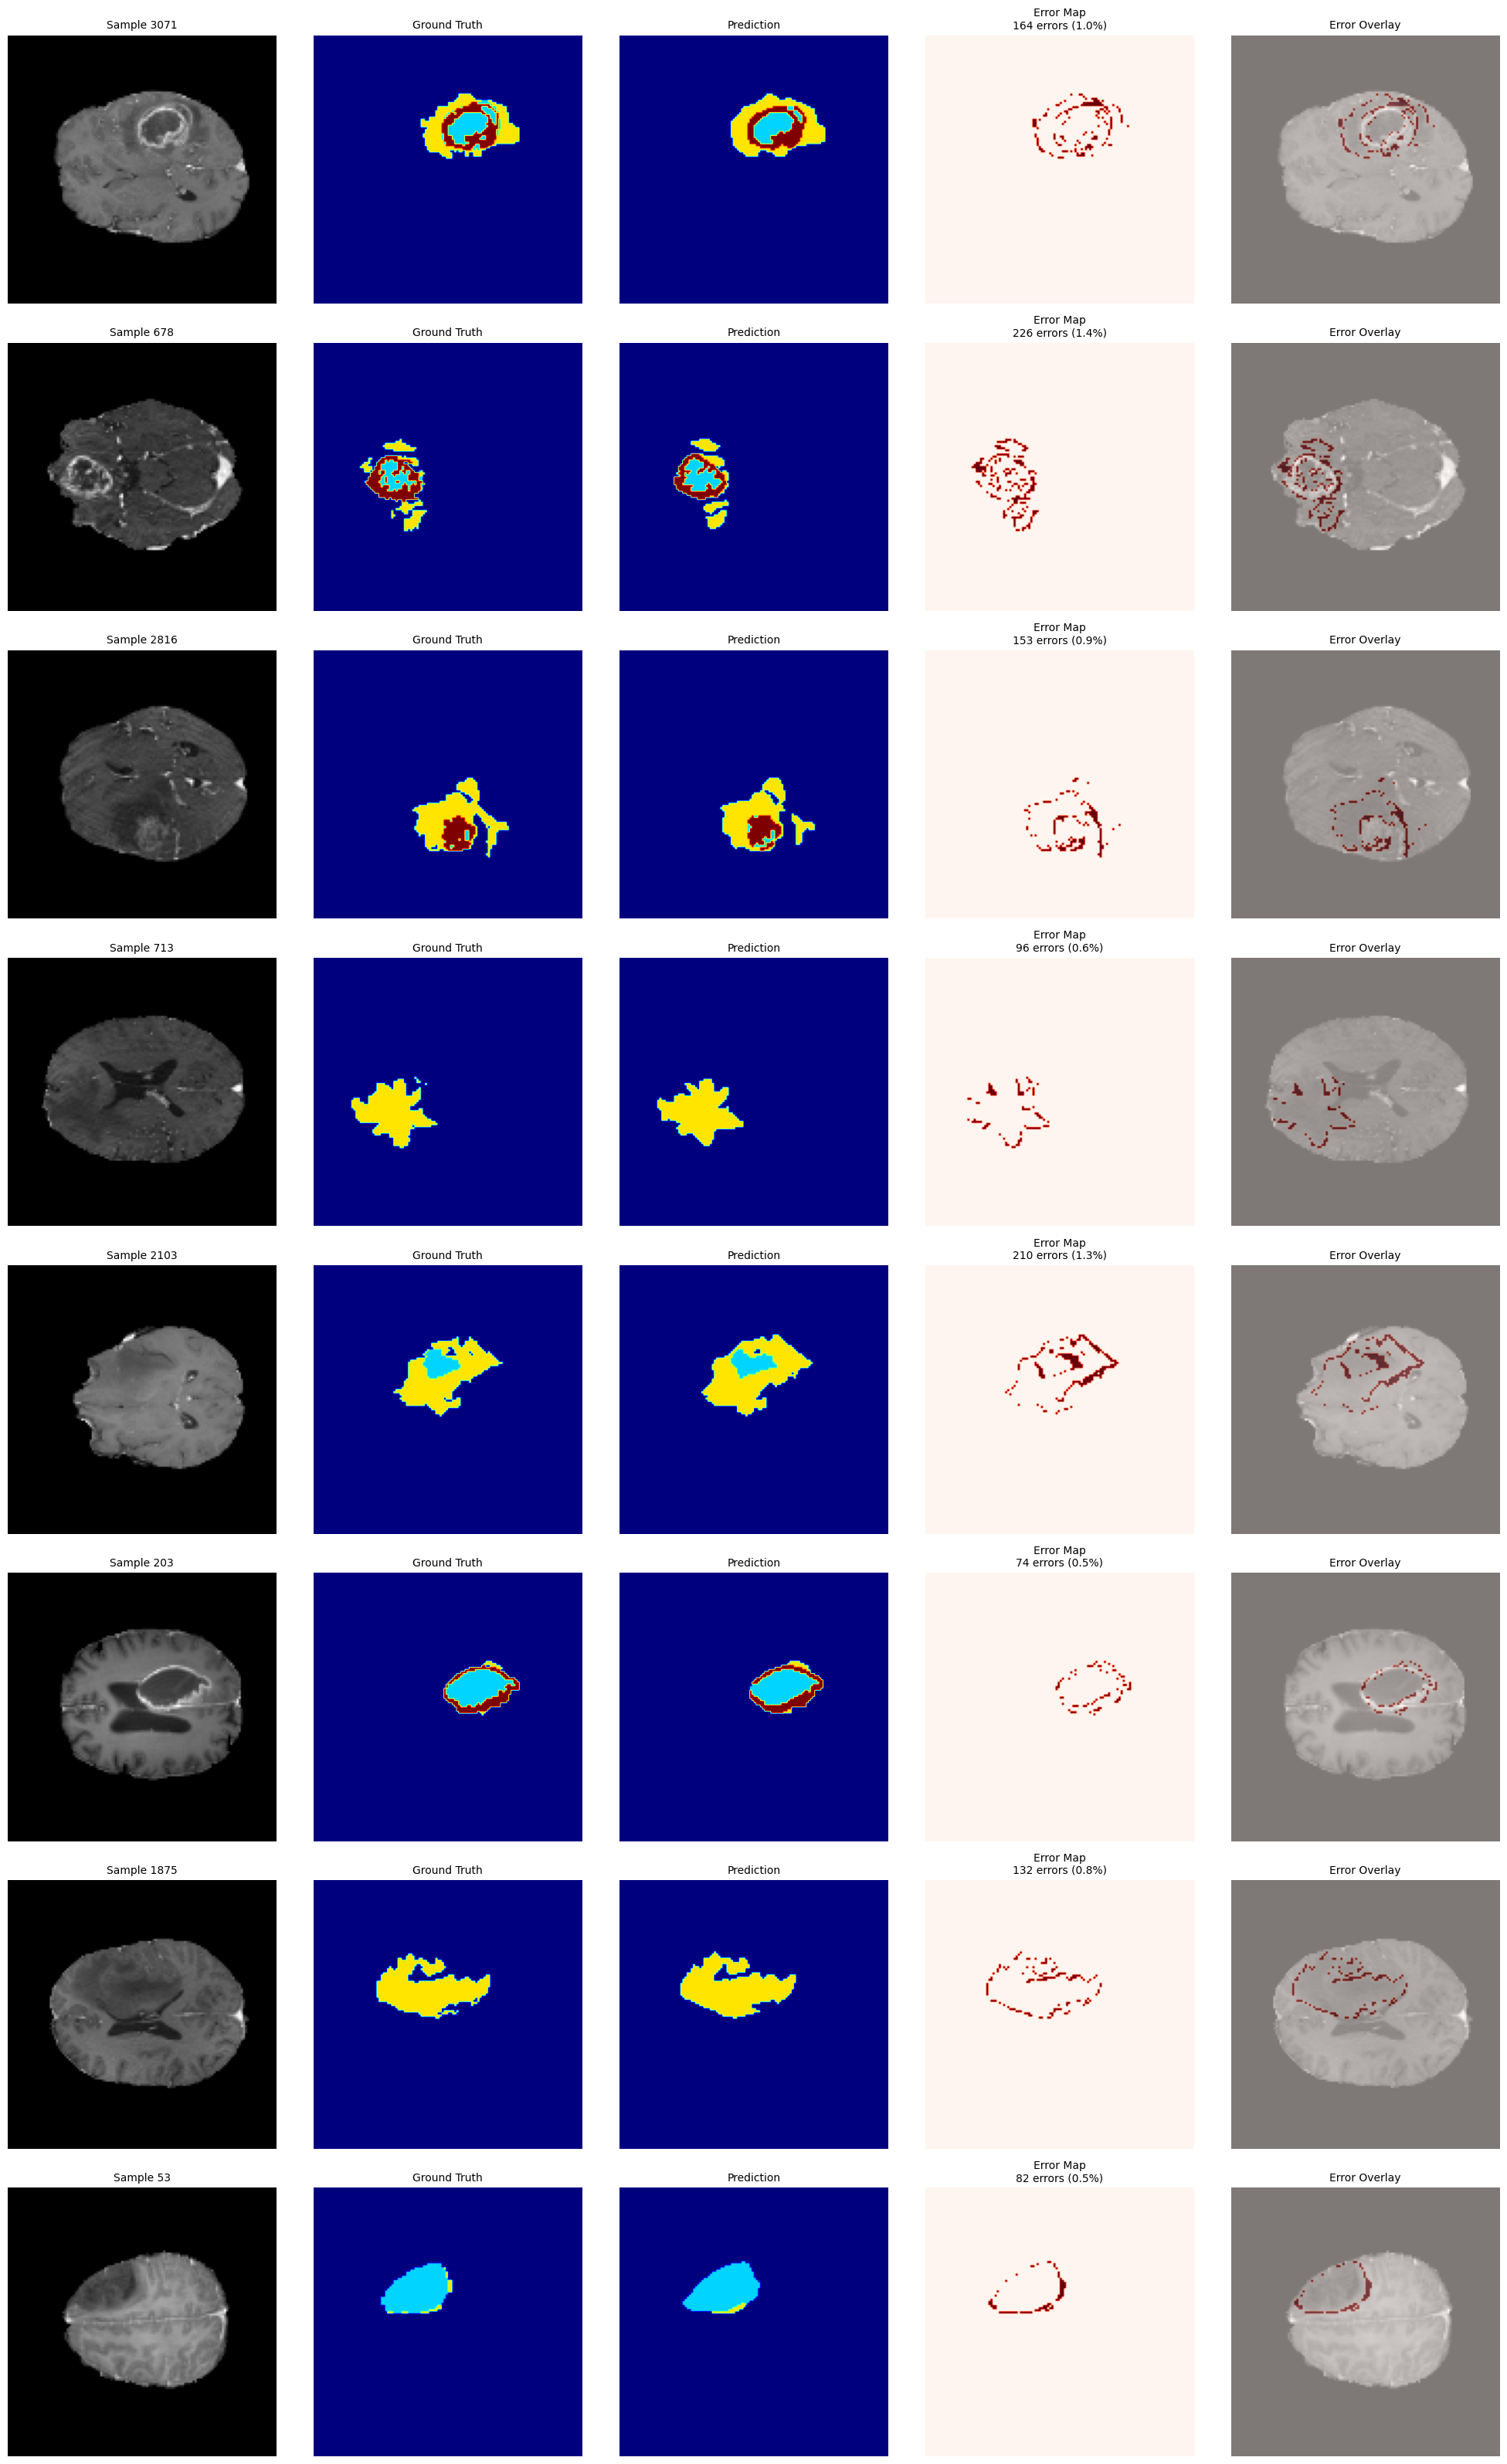


📊 ERROR STATISTICS:
   Total pixels: 55,476,224
   Incorrect pixels: 495,907
   Error rate: 0.89%
   Pixel accuracy: 99.11%


In [29]:
def visualize_error_maps(images, true_masks, pred_masks, num_samples=8):
    """Visualize error/difference maps"""
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    
    for i, idx in enumerate(indices):
        # Original image
        axes[i, 0].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 0].set_title(f'Sample {idx}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(true_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 1].set_title('Ground Truth', fontsize=10)
        axes[i, 1].axis('off')
        
        # Prediction
        axes[i, 2].imshow(pred_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 2].set_title('Prediction', fontsize=10)
        axes[i, 2].axis('off')
        
        # Error map
        error_map = (true_masks[idx] != pred_masks[idx]).astype(np.uint8)
        error_count = np.sum(error_map)
        total_pixels = error_map.size
        error_pct = (error_count / total_pixels) * 100
        
        axes[i, 3].imshow(error_map, cmap='Reds', vmin=0, vmax=1)
        axes[i, 3].set_title(f'Error Map\n{error_count} errors ({error_pct:.1f}%)', fontsize=10)
        axes[i, 3].axis('off')
        
        # Overlay error
        axes[i, 4].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 4].imshow(error_map, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i, 4].set_title('Error Overlay', fontsize=10)
        axes[i, 4].axis('off')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/vit_error_maps.png', dpi=300, bbox_inches='tight')
    plt.show()

print("="*70)
print("VISUALIZING ERROR MAPS")
print("="*70)

visualize_error_maps(test_images, test_masks, test_predictions_classes, num_samples=8)

# Calculate error statistics
total_pixels = test_masks.size
error_pixels = np.sum(test_masks != test_predictions_classes)
error_rate = (error_pixels / total_pixels) * 100

print(f"\n📊 ERROR STATISTICS:")
print(f"   Total pixels: {total_pixels:,}")
print(f"   Incorrect pixels: {error_pixels:,}")
print(f"   Error rate: {error_rate:.2f}%")
print(f"   Pixel accuracy: {100-error_rate:.2f}%")

# Class-wise Metrics

CLASS-WISE EVALUATION METRICS
Class           Dice Score      IoU Score      
----------------------------------------------------------------------
Background      0.9970          0.9941         
Necrotic        0.7254          0.5691         
Edema           0.8040          0.6723         
Enhancing       0.7714          0.6278         
----------------------------------------------------------------------
Mean            0.8245          0.7158         


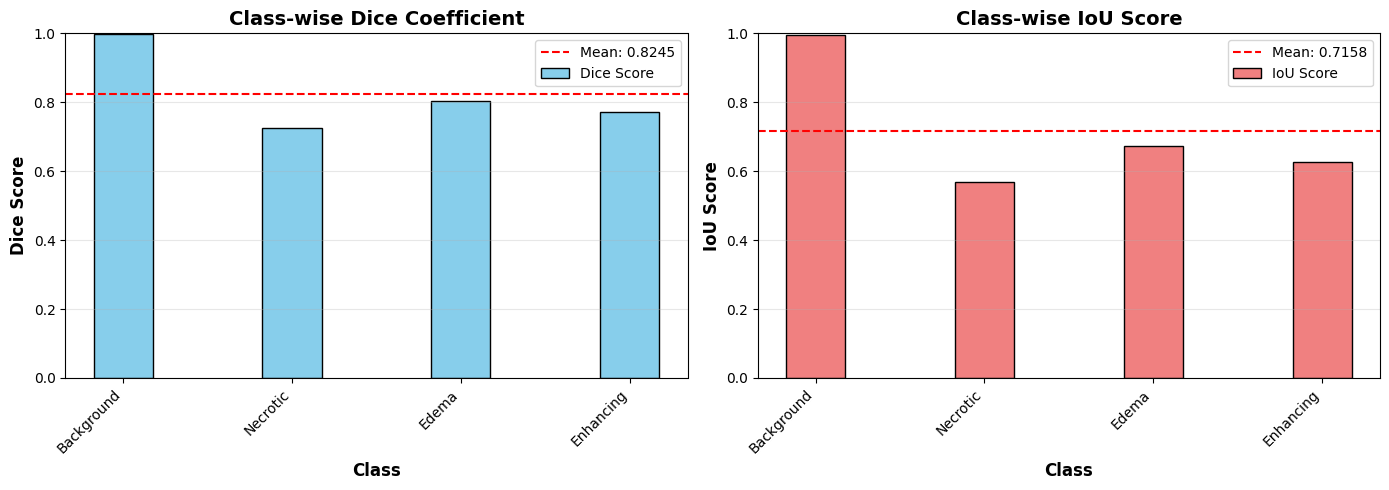

In [30]:
def calculate_class_wise_metrics(true_masks, pred_masks, num_classes=4):
    """Calculate class-wise Dice and IoU"""
    dice_scores = []
    iou_scores = []
    
    for class_id in range(num_classes):
        true_binary = (true_masks == class_id).astype(np.float32)
        pred_binary = (pred_masks == class_id).astype(np.float32)
        
        intersection = np.sum(true_binary * pred_binary)
        true_sum = np.sum(true_binary)
        pred_sum = np.sum(pred_binary)
        union = true_sum + pred_sum - intersection
        
        # Dice
        if true_sum + pred_sum > 0:
            dice = (2 * intersection) / (true_sum + pred_sum)
        else:
            dice = 1.0
        
        # IoU
        if union > 0:
            iou = intersection / union
        else:
            iou = 1.0
        
        dice_scores.append(dice)
        iou_scores.append(iou)
    
    return dice_scores, iou_scores

# Calculate metrics
class_dice, class_iou = calculate_class_wise_metrics(test_masks, test_predictions_classes, config.NUM_CLASSES)
class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']

print("="*70)
print("CLASS-WISE EVALUATION METRICS")
print("="*70)
print(f"{'Class':<15} {'Dice Score':<15} {'IoU Score':<15}")
print("-"*70)
for i, name in enumerate(class_names):
    print(f"{name:<15} {class_dice[i]:<15.4f} {class_iou[i]:<15.4f}")
print("-"*70)
print(f"{'Mean':<15} {np.mean(class_dice):<15.4f} {np.mean(class_iou):<15.4f}")
print("="*70)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(class_names))
width = 0.35

axes[0].bar(x, class_dice, width, label='Dice Score', color='skyblue', edgecolor='black')
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Dice Score', fontsize=12, fontweight='bold')
axes[0].set_title('Class-wise Dice Coefficient', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=np.mean(class_dice), color='red', linestyle='--', label=f'Mean: {np.mean(class_dice):.4f}')
axes[0].legend()

axes[1].bar(x, class_iou, width, label='IoU Score', color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('IoU Score', fontsize=12, fontweight='bold')
axes[1].set_title('Class-wise IoU Score', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=np.mean(class_iou), color='red', linestyle='--', label=f'Mean: {np.mean(class_iou):.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/vit_classwise_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix

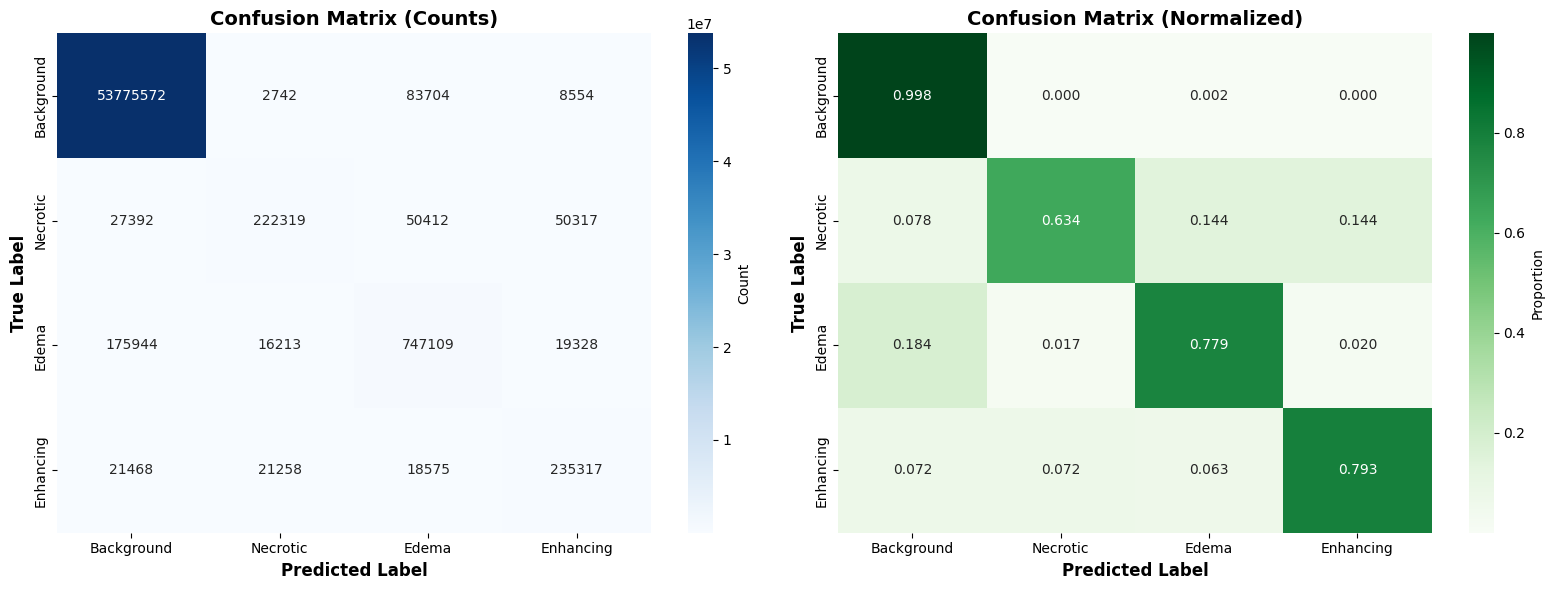

CONFUSION MATRIX GENERATED


In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(test_masks.flatten(), test_predictions_classes.flatten())
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/vit_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print("CONFUSION MATRIX GENERATED")
print("="*70)

#  Comprehensive Metrics

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9958    0.9982    0.9970  53870572
    Necrotic     0.8468    0.6344    0.7254    350440
       Edema     0.8303    0.7794    0.8040    958594
   Enhancing     0.7506    0.7933    0.7714    296618

    accuracy                         0.9911  55476224
   macro avg     0.8559    0.8013    0.8245  55476224
weighted avg     0.9907    0.9911    0.9908  55476224


COMPREHENSIVE METRICS SUMMARY
     Class     Dice      IoU  Precision   Recall  F1-Score
Background 0.997035 0.994089   0.995837 0.998237  0.997035
  Necrotic 0.725381 0.569096   0.846826 0.634400  0.725381
     Edema 0.804037 0.672293   0.830306 0.779380  0.804037
 Enhancing 0.771362 0.627818   0.750574 0.793334  0.771362

✅ Metrics saved to 'vit_evaluation_metrics.csv'


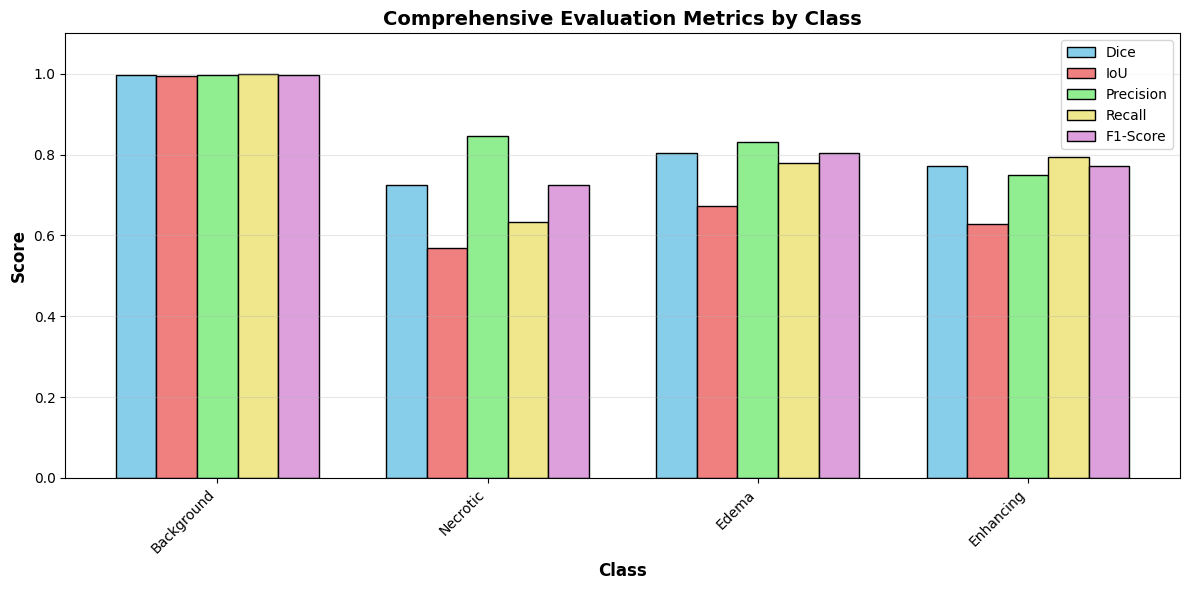

In [32]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Flatten arrays
y_true = test_masks.flatten()
y_pred = test_predictions_classes.flatten()

# Calculate metrics
precision = precision_score(y_true, y_pred, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

print("="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Summary table
summary_data = {
    'Class': class_names,
    'Dice': class_dice,
    'IoU': class_iou,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save to CSV
summary_df.to_csv('/kaggle/working/vit_evaluation_metrics.csv', index=False)
print("\n✅ Metrics saved to 'vit_evaluation_metrics.csv'")

# Visualize all metrics
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.15

ax.bar(x - 2*width, class_dice, width, label='Dice', color='skyblue', edgecolor='black')
ax.bar(x - width, class_iou, width, label='IoU', color='lightcoral', edgecolor='black')
ax.bar(x, precision, width, label='Precision', color='lightgreen', edgecolor='black')
ax.bar(x + width, recall, width, label='Recall', color='khaki', edgecolor='black')
ax.bar(x + 2*width, f1, width, label='F1-Score', color='plum', edgecolor='black')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Evaluation Metrics by Class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylim([0, 1.1])
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/vit_comprehensive_metrics.png', dpi=300, bbox_inches='tight')
plt.show()